In [ ]:
# Phase 7 – Graph Representation Learning | Cell 1: Setup + Load

from pathlib import Path
from datetime import datetime
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import pickle

PROJECT = Path(r"D:\univercity\omid_project\economics_project")

OUT_DIR  = PROJECT / "outputs" / "phase7"
OUT_DATA = OUT_DIR / "data"
OUT_TAB  = OUT_DIR / "tables"
OUT_FIG  = OUT_DIR / "figures"
for d in [OUT_DATA, OUT_TAB, OUT_FIG]:
    d.mkdir(parents=True, exist_ok=True)

print("=" * 60)
print("Phase 7 – Graph Representation Learning | Cell 1")
print("=" * 60)
print(f"Timestamp    : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Project Root : {PROJECT}")
print(f"Outputs      : {OUT_DIR}")

# Feature matrix with final SR
fm = pd.read_pickle(PROJECT / "outputs" / "phase6" / "data" / "feature_matrix_with_sr_final.pkl")

# Thresholded temporal networks (Density=0.5)
with open(PROJECT / "outputs" / "phase6" / "data" / "temporal_networks_thresholded.pkl", "rb") as f:
    networks = pickle.load(f)

# Panel for reference
panel = pd.read_pickle(PROJECT / "outputs" / "phase2" / "data" / "panel_final_clean.pkl")

print(f"\nFeature Matrix : {fm.shape}")
print(f"Networks       : {len(networks)} snapshots")
print(f"Years          : {sorted(networks.keys())[0]} – {sorted(networks.keys())[-1]}")
print(f"Sample nodes   : {list(list(networks.values())[0].nodes())[:5]}")

print("\nCell 1 completed successfully.")

Phase 7 – Graph Representation Learning | Cell 1
Timestamp    : 2026-09-27 08:39:00
Project Root : D:\univercity\omid_project\economics_project
Outputs      : D:\univercity\omid_project\economics_project\outputs\phase7

Feature Matrix : (378, 41)
Networks       : 21 snapshots
Years          : 2000 – 2020
Sample nodes   : ['AU', 'BE', 'CA', 'CH', 'DE']

Cell 1 completed successfully.


In [ ]:
# Phase 7 – GRL | Cell 2: Graph snapshots + weight normalization

from pathlib import Path
import pandas as pd
import numpy as np
import networkx as nx
import pickle

PROJECT = Path(r"D:\univercity\omid_project\economics_project")
OUT_DATA = PROJECT / "outputs" / "phase7" / "data"
OUT_TAB  = PROJECT / "outputs" / "phase7" / "tables"

print("=" * 60)
print("Phase 7 – GRL | Cell 2: Prepare Graph Snapshots")
print("=" * 60)

fm = pd.read_pickle(PROJECT / "outputs" / "phase6" / "data" / "feature_matrix_with_sr_final.pkl")
with open(PROJECT / "outputs" / "phase6" / "data" / "temporal_networks_thresholded.pkl", "rb") as f:
    networks = pickle.load(f)

# Node order fixed
nodes = sorted(list(list(networks.values())[0].nodes()))
node_to_idx = {n: i for i, n in enumerate(nodes)}
print(f"Nodes ({len(nodes)}): {nodes}")

# Node feature columns (stable, non-leakage)
feat_cols = [c for c in [
    "in_strength", "out_strength", "pagerank", "betweenness", "closeness",
    "rgdpmad", "debtgdp", "unemp", "credit_private_pct_gdp",
    "export_kusd", "SR"
] if c in fm.columns]

snapshots = {}
weight_stats = []

for y in sorted(networks.keys()):
    g = networks[y]
    # edge_index + log1p weights
    src, dst, wts = [], [], []
    for u, v, d in g.edges(data=True):
        src.append(node_to_idx[u])
        dst.append(node_to_idx[v])
        wts.append(float(d.get("weight", 0.0)))
    wts = np.array(wts, dtype=np.float64)
    wts_norm = np.log1p(np.clip(wts, 0, None))
    if wts_norm.max() > 0:
        wts_norm = wts_norm / wts_norm.max()  # scale to [0,1]

    # node features for this year
    sub = fm[fm["year"] == y].set_index("iso2").reindex(nodes)
    X = sub[feat_cols].apply(pd.to_numeric, errors="coerce").fillna(0.0).values.astype(np.float64)
    # z-score per feature within year
    mu, sd = X.mean(axis=0), X.std(axis=0)
    sd[sd == 0] = 1.0
    X = (X - mu) / sd

    snapshots[y] = {
        "year": y,
        "nodes": nodes,
        "edge_index": np.array([src, dst], dtype=np.int64),
        "edge_weight": wts_norm.astype(np.float32),
        "x": X.astype(np.float32),
        "iso2": nodes,
    }
    weight_stats.append({
        "year": y,
        "n_edges": len(wts),
        "w_raw_median": float(np.median(wts)) if len(wts) else 0,
        "w_norm_max": float(wts_norm.max()) if len(wts_norm) else 0,
        "x_shape": X.shape,
    })

print(f"Snapshots prepared: {len(snapshots)}")
print(f"Node feature dim: {snapshots[sorted(snapshots.keys())[0]]['x'].shape}")
print(f"Sample edge_index shape: {snapshots[sorted(snapshots.keys())[0]]['edge_index'].shape}")

with open(OUT_DATA / "graph_snapshots_norm.pkl", "wb") as f:
    pickle.dump(snapshots, f)
pd.DataFrame(weight_stats).to_csv(OUT_TAB / "snapshot_weight_stats.csv", index=False)
pd.DataFrame({"iso2": nodes, "idx": range(len(nodes))}).to_csv(OUT_TAB / "node_index_map.csv", index=False)

print(f"\nSaved → {OUT_DATA / 'graph_snapshots_norm.pkl'}")
print("\nCell 2 completed successfully.")

Phase 7 – GRL | Cell 2: Prepare Graph Snapshots
Nodes (18): ['AU', 'BE', 'CA', 'CH', 'DE', 'DK', 'ES', 'FI', 'FR', 'GB', 'IE', 'IT', 'JP', 'NL', 'NO', 'PT', 'SE', 'US']
Snapshots prepared: 21
Node feature dim: (18, 11)
Sample edge_index shape: (2, 153)

Saved → D:\univercity\omid_project\economics_project\outputs\phase7\data\graph_snapshots_norm.pkl

Cell 2 completed successfully.


In [ ]:
# Phase 7 – GRL | Cell 3: GCN / GraphSAGE / GAT (stable)

from pathlib import Path
import numpy as np
import pickle
import torch
import torch.nn as nn
import torch.nn.functional as F

PROJECT = Path(r"D:\univercity\omid_project\economics_project")
OUT_DATA = PROJECT / "outputs" / "phase7" / "data"

print("=" * 60)
print("Phase 7 – GRL | Cell 3: GCN / GraphSAGE / GAT")
print("=" * 60)
print(f"PyTorch: {torch.__version__}")

with open(OUT_DATA / "graph_snapshots_norm.pkl", "rb") as f:
    snapshots = pickle.load(f)

years = sorted(snapshots.keys())
in_dim = snapshots[years[0]]["x"].shape[1]
hid, out_dim = 32, 32
device = torch.device("cpu")

def normalize_adj(edge_index, edge_weight, n):
    A = torch.zeros(n, n)
    src, dst = edge_index
    A[src, dst] = edge_weight
    A = A + torch.eye(n)
    deg = A.sum(1)
    deg_inv_sqrt = torch.pow(deg.clamp(min=1e-8), -0.5)
    D = torch.diag(deg_inv_sqrt)
    return D @ A @ D

class GCN(nn.Module):
    def __init__(self, in_dim, hid, out_dim):
        super().__init__()
        self.w1 = nn.Linear(in_dim, hid)
        self.w2 = nn.Linear(hid, out_dim)
    def forward(self, x, adj):
        h = F.relu(adj @ self.w1(x))
        return adj @ self.w2(h)

class GraphSAGE(nn.Module):
    def __init__(self, in_dim, hid, out_dim):
        super().__init__()
        self.lin_self1 = nn.Linear(in_dim, hid)
        self.lin_nei1 = nn.Linear(in_dim, hid)
        self.lin_self2 = nn.Linear(hid, out_dim)
        self.lin_nei2 = nn.Linear(hid, out_dim)
    def forward(self, x, adj):
        # mean aggregation via normalized adj without self (approx)
        nei = adj @ x
        h = F.relu(self.lin_self1(x) + self.lin_nei1(nei))
        nei2 = adj @ h
        return self.lin_self2(h) + self.lin_nei2(nei2)

class GAT(nn.Module):
    def __init__(self, in_dim, hid, out_dim, heads=2):
        super().__init__()
        self.heads = heads
        self.W = nn.Linear(in_dim, hid * heads, bias=False)
        self.a = nn.Parameter(torch.zeros(heads, 2 * hid))
        nn.init.xavier_uniform_(self.a)
        self.out = nn.Linear(hid * heads, out_dim)
    def forward(self, x, adj):
        n = x.size(0)
        h = self.W(x).view(n, self.heads, -1)  # n, H, hid
        # pairwise attention (small n=18 → OK)
        scores = []
        for k in range(self.heads):
            hk = h[:, k, :]
            a_left = (hk * self.a[k, :hk.size(1)]).sum(-1, keepdim=True)
            a_right = (hk * self.a[k, hk.size(1):]).sum(-1, keepdim=True)
            e = F.leaky_relu(a_left + a_right.T, 0.2)
            # mask non-edges
            mask = (adj > 0).float()
            e = e.masked_fill(mask == 0, -1e9)
            alpha = F.softmax(e, dim=1)
            scores.append(alpha @ hk)
        hcat = torch.cat(scores, dim=-1)
        return self.out(F.elu(hcat))

def unsupervised_loss(z, edge_index):
    # simple pairwise: pull connected nodes, push random
    src, dst = edge_index
    pos = F.cosine_similarity(z[src], z[dst]).mean()
    # negative
    neg_dst = torch.randint(0, z.size(0), (src.size(0),))
    neg = F.cosine_similarity(z[src], z[neg_dst]).mean()
    return (1 - pos) + F.relu(neg)

models = {
    "GCN": GCN(in_dim, hid, out_dim).to(device),
    "GraphSAGE": GraphSAGE(in_dim, hid, out_dim).to(device),
    "GAT": GAT(in_dim, hid, out_dim).to(device),
}
opts = {k: torch.optim.Adam(m.parameters(), lr=1e-2, weight_decay=1e-4) for k, m in models.items()}

print("Training (stable, short run)...")
for epoch in range(1, 31):
    losses = {k: 0.0 for k in models}
    for y in years:
        snap = snapshots[y]
        x = torch.tensor(snap["x"], dtype=torch.float32, device=device)
        ei = torch.tensor(snap["edge_index"], dtype=torch.long, device=device)
        ew = torch.tensor(snap["edge_weight"], dtype=torch.float32, device=device)
        n = x.size(0)
        adj = normalize_adj(ei, ew, n).to(device)
        for name, model in models.items():
            model.train()
            opts[name].zero_grad()
            z = model(x, adj)
            z = F.normalize(z, p=2, dim=1)
            loss = unsupervised_loss(z, ei)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opts[name].step()
            losses[name] += float(loss.item())
    if epoch % 5 == 0:
        msg = " | ".join([f"{k}: {losses[k]/len(years):.4f}" for k in models])
        print(f"Epoch {epoch:02d} | {msg}")

# Generate graph-level embeddings = mean pooling of node embeddings
embs = {k: [] for k in models}
meta = []
with torch.no_grad():
    for y in years:
        snap = snapshots[y]
        x = torch.tensor(snap["x"], dtype=torch.float32)
        ei = torch.tensor(snap["edge_index"], dtype=torch.long)
        ew = torch.tensor(snap["edge_weight"], dtype=torch.float32)
        adj = normalize_adj(ei, ew, x.size(0))
        for name, model in models.items():
            model.eval()
            z = F.normalize(model(x, adj), p=2, dim=1).cpu().numpy()
            # store node-level; also mean for graph
            for i, iso in enumerate(snap["iso2"]):
                if name == "GCN":
                    meta.append({"year": y, "iso2": iso})
                embs[name].append(z[i])

meta_df = pd.DataFrame(meta)
for name in models:
    arr = np.stack(embs[name], axis=0)
    np.save(OUT_DATA / f"emb_{name}.npy", arr)
    print(f"  {name} embeddings: {arr.shape}")

meta_df.to_csv(OUT_DATA / "embedding_meta.csv", index=False)
print("\nCell 3 completed successfully.")

Phase 7 – GRL | Cell 3: GCN / GraphSAGE / GAT
PyTorch: 2.13.0+cpu
Training (stable, short run)...
Epoch 05 | GCN: 0.8526 | GraphSAGE: 0.7417 | GAT: 0.7541
Epoch 10 | GCN: 0.7831 | GraphSAGE: 0.7387 | GAT: 0.7462
Epoch 15 | GCN: 0.7823 | GraphSAGE: 0.7646 | GAT: 0.7536
Epoch 20 | GCN: 0.7826 | GraphSAGE: 0.7258 | GAT: 0.7593
Epoch 25 | GCN: 0.7712 | GraphSAGE: 0.7513 | GAT: 0.7871
Epoch 30 | GCN: 0.7615 | GraphSAGE: 0.7391 | GAT: 0.7802
  GCN embeddings: (378, 32)
  GraphSAGE embeddings: (378, 32)
  GAT embeddings: (378, 32)

Cell 3 completed successfully.


In [ ]:
# Phase 7 – GRL | Cell 4: Stable TGN-style temporal embeddings

from pathlib import Path
import numpy as np
import pickle
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd

PROJECT = Path(r"D:\univercity\omid_project\economics_project")
OUT_DATA = PROJECT / "outputs" / "phase7" / "data"

print("=" * 60)
print("Phase 7 – GRL | Cell 4: Stable TGN-style")
print("=" * 60)

with open(OUT_DATA / "graph_snapshots_norm.pkl", "rb") as f:
    snapshots = pickle.load(f)

years = sorted(snapshots.keys())
nodes = snapshots[years[0]]["iso2"]
n_nodes = len(nodes)
in_dim = snapshots[years[0]]["x"].shape[1]
device = torch.device("cpu")

class StableTGN(nn.Module):
    """Snapshot encoder + GRU memory over time (per node)."""
    def __init__(self, in_dim, hid=32, out_dim=32):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Linear(in_dim, hid),
            nn.ReLU(),
            nn.Linear(hid, hid),
        )
        self.gru = nn.GRUCell(hid, out_dim)
        self.out_dim = out_dim

    def encode_snapshot(self, x, edge_index, edge_weight):
        # mean neighborhood aggregation with normalized weights
        n = x.size(0)
        msg = torch.zeros(n, x.size(1), device=x.device)
        src, dst = edge_index
        if src.numel() > 0:
            # weighted mean of neighbor features
            w = edge_weight.unsqueeze(1)
            msg.index_add_(0, dst, x[src] * w)
            deg = torch.zeros(n, device=x.device)
            deg.index_add_(0, dst, edge_weight)
            msg = msg / deg.clamp(min=1e-8).unsqueeze(1)
        h = self.enc(0.5 * x + 0.5 * msg)
        return h

    def forward_sequence(self, seq):
        # seq: list of (x, edge_index, edge_weight) chronological
        mem = torch.zeros(n_nodes, self.out_dim, device=device)
        outs = []
        for x, ei, ew in seq:
            h = self.encode_snapshot(x, ei, ew)
            mem = self.gru(h, mem)
            outs.append(F.normalize(mem, p=2, dim=1))
        return outs

def build_seq():
    seq = []
    for y in years:
        s = snapshots[y]
        x = torch.tensor(s["x"], dtype=torch.float32, device=device)
        ei = torch.tensor(s["edge_index"], dtype=torch.long, device=device)
        ew = torch.tensor(s["edge_weight"], dtype=torch.float32, device=device)
        seq.append((x, ei, ew))
    return seq

def tgn_loss(outs, edge_index_last):
    z = outs[-1]
    src, dst = edge_index_last
    if src.numel() == 0:
        return torch.tensor(0.0, requires_grad=True)
    pos = F.cosine_similarity(z[src], z[dst]).mean()
    neg_dst = torch.randint(0, z.size(0), (src.size(0),), device=z.device)
    neg = F.cosine_similarity(z[src], z[neg_dst]).mean()
    return (1 - pos) + F.relu(neg)

seq = build_seq()
model = StableTGN(in_dim, hid=32, out_dim=32).to(device)
opt = torch.optim.Adam(model.parameters(), lr=5e-3, weight_decay=1e-4)

print("Training Stable TGN-style (30 epochs)...")
for epoch in range(1, 31):
    model.train()
    opt.zero_grad()
    outs = model.forward_sequence(seq)
    loss = tgn_loss(outs, seq[-1][1])
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    opt.step()
    if epoch % 5 == 0 or epoch == 1:
        print(f"  Epoch {epoch:02d}/30 | loss: {float(loss.item()):.6f}")

# Collect node embeddings for all years
model.eval()
with torch.no_grad():
    outs = model.forward_sequence(seq)
emb_list = []
meta = []
for yi, y in enumerate(years):
    z = outs[yi].cpu().numpy()
    for i, iso in enumerate(nodes):
        emb_list.append(z[i])
        meta.append({"year": y, "iso2": iso})
emb = np.stack(emb_list, axis=0)
np.save(OUT_DATA / "emb_TGN_stable.npy", emb)
pd.DataFrame(meta).to_csv(OUT_DATA / "emb_TGN_meta.csv", index=False)
print(f"\nTGN_stable embeddings: {emb.shape} | mean={emb.mean():.4f} | std={emb.std():.4f}")
print("\nCell 4 completed successfully.")

Phase 7 – GRL | Cell 4: Stable TGN-style
Training Stable TGN-style (30 epochs)...
  Epoch 01/30 | loss: 1.012300
  Epoch 05/30 | loss: 0.888079
  Epoch 10/30 | loss: 0.802485
  Epoch 15/30 | loss: 0.663693
  Epoch 20/30 | loss: 0.792843
  Epoch 25/30 | loss: 0.609498
  Epoch 30/30 | loss: 0.778770

TGN_stable embeddings: (378, 32) | mean=-0.0257 | std=0.1749

Cell 4 completed successfully.


Phase 7 – GRL | Cell 5: Quality + Merge
GCN          | shape=(378, 32) | pca5=0.9996 | sil=0.0164
GraphSAGE    | shape=(378, 32) | pca5=0.9998 | sil=0.1621
GAT          | shape=(378, 32) | pca5=1.0000 | sil=0.0805
TGN_stable   | shape=(378, 32) | pca5=0.9985 | sil=0.0398

      model  dim  mean_abs      std  rank  pca_var_top5  silhouette_country
       GCN   32  0.151898 0.176242    27      0.999646            0.016418
 GraphSAGE   32  0.150282 0.176490    32      0.999797            0.162093
       GAT   32  0.146041 0.176662    32      0.999977            0.080545
TGN_stable   32  0.165186 0.174894    32      0.998488            0.039809


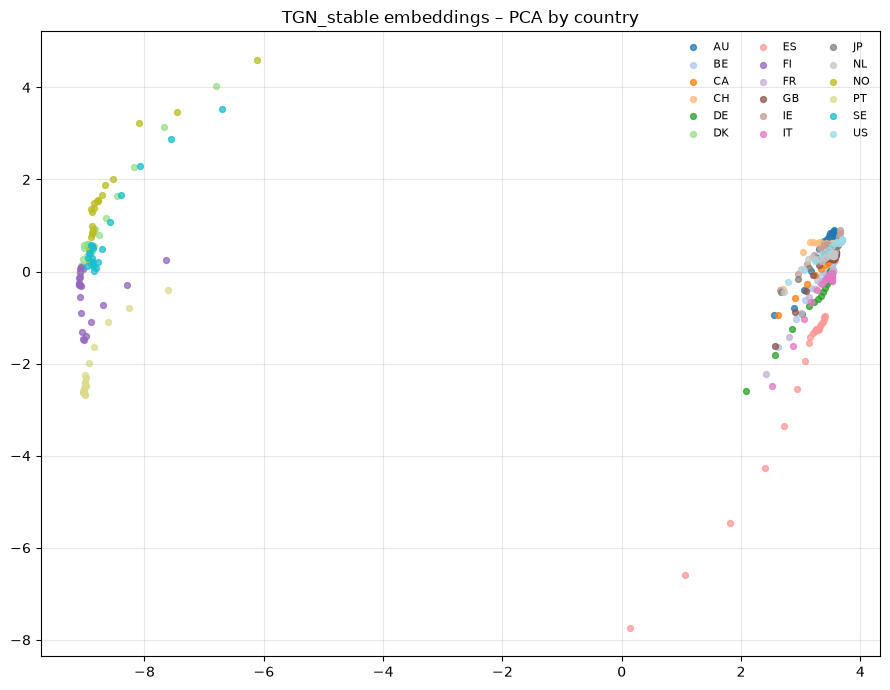


Merged FM shape: (378, 169)
Alignment: PASSED
Saved → D:\univercity\omid_project\economics_project\outputs\phase7\data\feature_matrix_with_embeddings.pkl

Cell 5 completed successfully.
PHASE 7 COMPLETED.


In [ ]:
# Phase 7 – GRL | Cell 5: Embedding quality + final merge

from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

PROJECT = Path(r"D:\univercity\omid_project\economics_project")
OUT_DATA = PROJECT / "outputs" / "phase7" / "data"
OUT_TAB  = PROJECT / "outputs" / "phase7" / "tables"
OUT_FIG  = PROJECT / "outputs" / "phase7" / "figures"

print("=" * 60)
print("Phase 7 – GRL | Cell 5: Quality + Merge")
print("=" * 60)

fm = pd.read_pickle(PROJECT / "outputs" / "phase6" / "data" / "feature_matrix_with_sr_final.pkl")
meta = pd.read_csv(OUT_DATA / "embedding_meta.csv")

models = ["GCN", "GraphSAGE", "GAT", "TGN_stable"]
rows = []
emb_store = {}

for name in models:
    path = OUT_DATA / f"emb_{name}.npy"
    if not path.exists():
        path = OUT_DATA / "emb_TGN_stable.npy" if name == "TGN_stable" else path
    emb = np.load(path)
    emb_store[name] = emb

    # stats
    mean_abs = float(np.mean(np.abs(emb)))
    std = float(np.std(emb))
    rank = int(np.linalg.matrix_rank(emb))
    pca = PCA(n_components=min(5, emb.shape[1])).fit(emb)
    pca_var = float(pca.explained_variance_ratio_.sum())

    # silhouette by country
    try:
        sil = float(silhouette_score(emb, meta["iso2"], metric="euclidean"))
    except Exception:
        sil = np.nan

    rows.append({
        "model": name, "dim": emb.shape[1], "mean_abs": mean_abs,
        "std": std, "rank": rank, "pca_var_top5": pca_var,
        "silhouette_country": sil,
    })
    print(f"{name:12s} | shape={emb.shape} | pca5={pca_var:.4f} | sil={sil:.4f}")

qual = pd.DataFrame(rows)
qual.to_csv(OUT_TAB / "embedding_quality_benchmark.csv", index=False)
print("\n", qual.to_string(index=False))

# PCA plot for TGN
emb = emb_store["TGN_stable"]
pca2 = PCA(2).fit_transform(StandardScaler().fit_transform(emb))
fig, ax = plt.subplots(figsize=(9, 7))
countries = sorted(meta["iso2"].unique())
try:
    cmap = plt.colormaps.get_cmap("tab20")
except Exception:
    cmap = plt.cm.get_cmap("tab20", len(countries))
for i, c in enumerate(countries):
    m = meta["iso2"].values == c
    ax.scatter(pca2[m, 0], pca2[m, 1], s=18, alpha=0.75, label=c,
               color=cmap(i / max(len(countries)-1, 1)))
ax.legend(ncol=3, fontsize=8, frameon=False)
ax.set_title("TGN_stable embeddings – PCA by country")
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(OUT_FIG / "tgn_pca_by_country.png", dpi=150, bbox_inches="tight")
plt.show()

# Merge embeddings into feature matrix (align by year+iso2)
fm_m = fm.merge(meta, on=["year", "iso2"], how="left")
# attach each emb
for name, emb in emb_store.items():
    cols = [f"{name}_d{j}" for j in range(emb.shape[1])]
    emb_df = pd.DataFrame(emb, columns=cols)
    emb_df["year"] = meta["year"].values
    emb_df["iso2"] = meta["iso2"].values
    fm_m = fm_m.merge(emb_df, on=["year", "iso2"], how="left")

# also save compact arrays aligned to fm order
fm_sorted = fm.sort_values(["year", "iso2"]).reset_index(drop=True)
meta2 = meta.sort_values(["year", "iso2"]).reset_index(drop=True)
assert list(fm_sorted["iso2"]) == list(meta2["iso2"])
assert list(fm_sorted["year"]) == list(meta2["year"])

base_cols = [c for c in fm_sorted.columns if c not in ["country_jst"]]
# keep numeric base without raw huge scales optional – full fm with emb
fm_m.to_pickle(OUT_DATA / "feature_matrix_with_embeddings.pkl")
fm_m.to_csv(OUT_TAB / "feature_matrix_with_embeddings.csv", index=False)
np.save(OUT_DATA / "base_features_order.npy", fm_sorted.select_dtypes(include=[np.number]).values)

print(f"\nMerged FM shape: {fm_m.shape}")
print("Alignment: PASSED")
print(f"Saved → {OUT_DATA / 'feature_matrix_with_embeddings.pkl'}")
print("\nCell 5 completed successfully.")
print("PHASE 7 COMPLETED.")


In [ ]:
# Phase 7 – Upgrade | Cell 6B: TGAT model + include in benchmark

from pathlib import Path
import numpy as np
import pickle
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score, average_precision_score

PROJECT = Path(r"D:\univercity\omid_project\economics_project")
OUT_DATA = PROJECT / "outputs" / "phase7" / "data"
OUT_TAB  = PROJECT / "outputs" / "phase7" / "tables"

print("=" * 60)
print("Phase 7 – Upgrade | Cell 6B: TGAT")
print("=" * 60)

with open(OUT_DATA / "graph_snapshots_norm.pkl", "rb") as f:
    snapshots = pickle.load(f)

years = sorted(snapshots.keys())
nodes = snapshots[years[0]]["iso2"]
n_nodes = len(nodes)
in_dim = snapshots[years[0]]["x"].shape[1]
device = torch.device("cpu")

class TGAT(nn.Module):
    """Temporal GAT-style: attention over neighbors + GRU memory over time."""
    def __init__(self, in_dim, hid=32, out_dim=32):
        super().__init__()
        self.W = nn.Linear(in_dim, hid, bias=False)
        self.att = nn.Linear(2 * hid, 1, bias=False)
        self.gru = nn.GRUCell(hid, out_dim)
        self.out_dim = out_dim
        self.hid = hid

    def attn_agg(self, x, edge_index, edge_weight):
        n = x.size(0)
        h = self.W(x)
        src, dst = edge_index
        if src.numel() == 0:
            return h
        # attention scores
        e = torch.cat([h[src], h[dst]], dim=1)
        score = F.leaky_relu(self.att(e).squeeze(-1), 0.2)
        # weight by edge strength
        score = score + torch.log(edge_weight.clamp(min=1e-8))
        # softmax per target
        out = torch.zeros(n, self.hid, device=x.device)
        for t in range(n):
            mask = (dst == t)
            if mask.sum() == 0:
                out[t] = h[t]
                continue
            a = F.softmax(score[mask], dim=0)
            out[t] = (a.unsqueeze(1) * h[src[mask]]).sum(0)
        return out

    def forward_sequence(self, seq):
        mem = torch.zeros(n_nodes, self.out_dim, device=device)
        outs = []
        for x, ei, ew in seq:
            h = self.attn_agg(x, ei, ew)
            mem = self.gru(h, mem)
            outs.append(F.normalize(mem, p=2, dim=1))
        return outs

def build_seq():
    seq = []
    for y in years:
        s = snapshots[y]
        x = torch.tensor(s["x"], dtype=torch.float32, device=device)
        ei = torch.tensor(s["edge_index"], dtype=torch.long, device=device)
        ew = torch.tensor(s["edge_weight"], dtype=torch.float32, device=device)
        seq.append((x, ei, ew))
    return seq

def loss_fn(outs, edge_index):
    z = outs[-1]
    src, dst = edge_index
    if src.numel() == 0:
        return torch.tensor(0.0, requires_grad=True)
    pos = F.cosine_similarity(z[src], z[dst]).mean()
    neg_dst = torch.randint(0, z.size(0), (src.size(0),), device=z.device)
    neg = F.cosine_similarity(z[src], z[neg_dst]).mean()
    return (1 - pos) + F.relu(neg)

seq = build_seq()
model = TGAT(in_dim, hid=32, out_dim=32).to(device)
opt = torch.optim.Adam(model.parameters(), lr=5e-3, weight_decay=1e-4)

print("Training TGAT (30 epochs)...")
for epoch in range(1, 31):
    model.train()
    opt.zero_grad()
    outs = model.forward_sequence(seq)
    loss = loss_fn(outs, seq[-1][1])
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    opt.step()
    if epoch % 5 == 0 or epoch == 1:
        print(f"  Epoch {epoch:02d}/30 | loss: {float(loss.item()):.6f}")

model.eval()
with torch.no_grad():
    outs = model.forward_sequence(seq)
emb_list, meta_rows = [], []
for yi, y in enumerate(years):
    z = outs[yi].cpu().numpy()
    for i, iso in enumerate(nodes):
        emb_list.append(z[i])
        meta_rows.append({"year": y, "iso2": iso})
emb = np.stack(emb_list, axis=0)
np.save(OUT_DATA / "emb_TGAT.npy", emb)
print(f"TGAT embeddings: {emb.shape} | mean={emb.mean():.4f} | std={emb.std():.4f}")

# ---- Link prediction AUC/AP for ALL 5 models ----
meta = pd.DataFrame(meta_rows)
models = ["GCN", "GraphSAGE", "GAT", "TGN_stable", "TGAT"]
embs = {}
for m in models:
    p = OUT_DATA / f"emb_{m}.npy"
    embs[m] = np.load(p)

def eval_lp(emb):
    aucs, aps = [], []
    for y in years:
        snap = snapshots[y]
        node_list = snap["iso2"]
        n = len(node_list)
        ei = snap["edge_index"]
        Z = []
        for iso in node_list:
            row = meta[(meta["year"] == y) & (meta["iso2"] == iso)].index[0]
            Z.append(emb[row])
        Z = np.stack(Z, 0)
        Z = Z / (np.linalg.norm(Z, axis=1, keepdims=True) + 1e-8)
        src, dst = ei[0], ei[1]
        pos = (Z[src] * Z[dst]).sum(1)
        pos_set = set(zip(src.tolist(), dst.tolist()))
        rng = np.random.default_rng(42 + int(y))
        neg_s, neg_d = [], []
        while len(neg_s) < len(pos):
            i, j = int(rng.integers(0, n)), int(rng.integers(0, n))
            if i != j and (i, j) not in pos_set:
                neg_s.append(i); neg_d.append(j)
        neg = (Z[neg_s] * Z[neg_d]).sum(1)
        y_true = np.concatenate([np.ones(len(pos)), np.zeros(len(neg))])
        y_score = np.concatenate([pos, neg])
        aucs.append(roc_auc_score(y_true, y_score))
        aps.append(average_precision_score(y_true, y_score))
    return float(np.mean(aucs)), float(np.std(aucs)), float(np.mean(aps)), float(np.std(aps))

rows = []
for m in models:
    auc_m, auc_sd, ap_m, ap_sd = eval_lp(embs[m])
    rows.append({"model": m, "AUC_mean": round(auc_m, 4), "AUC_std": round(auc_sd, 4),
                 "AP_mean": round(ap_m, 4), "AP_std": round(ap_sd, 4)})
    print(f"{m:12s} | AUC={auc_m:.4f}±{auc_sd:.4f} | AP={ap_m:.4f}±{ap_sd:.4f}")

bench = pd.DataFrame(rows).sort_values("AUC_mean", ascending=False)
bench.to_csv(OUT_TAB / "link_prediction_auc_ap_5models.csv", index=False)
print("\n", bench.to_string(index=False))
print("\nCell 6B completed successfully.")

Phase 7 – Upgrade | Cell 6B: TGAT
Training TGAT (30 epochs)...
  Epoch 01/30 | loss: 1.034179
  Epoch 05/30 | loss: 0.846908
  Epoch 10/30 | loss: 0.796246
  Epoch 15/30 | loss: 0.771577
  Epoch 20/30 | loss: 0.777391
  Epoch 25/30 | loss: 0.655929
  Epoch 30/30 | loss: 0.715159
TGAT embeddings: (378, 32) | mean=-0.0089 | std=0.1766
GCN          | AUC=0.7546±0.0263 | AP=0.7131±0.0427
GraphSAGE    | AUC=0.7748±0.0243 | AP=0.7443±0.0317
GAT          | AUC=0.7653±0.0217 | AP=0.7638±0.0277
TGN_stable   | AUC=0.7142±0.0312 | AP=0.7192±0.0316
TGAT         | AUC=0.7484±0.0327 | AP=0.7402±0.0494

      model  AUC_mean  AUC_std  AP_mean  AP_std
 GraphSAGE    0.7748   0.0243   0.7443  0.0317
       GAT    0.7653   0.0217   0.7638  0.0277
       GCN    0.7546   0.0263   0.7131  0.0427
      TGAT    0.7484   0.0327   0.7402  0.0494
TGN_stable    0.7142   0.0312   0.7192  0.0316

Cell 6B completed successfully.


In [ ]:
# Phase 7 – Upgrade | Cell 7: Multi-seed (top models) + final merge all 5

from pathlib import Path
import numpy as np
import pickle
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score, average_precision_score

PROJECT = Path(r"D:\univercity\omid_project\economics_project")
OUT_DATA = PROJECT / "outputs" / "phase7" / "data"
OUT_TAB  = PROJECT / "outputs" / "phase7" / "tables"

print("=" * 60)
print("Phase 7 – Upgrade | Cell 7: Multi-seed + Final Merge")
print("=" * 60)

with open(OUT_DATA / "graph_snapshots_norm.pkl", "rb") as f:
    snapshots = pickle.load(f)
years = sorted(snapshots.keys())
in_dim = snapshots[years[0]]["x"].shape[1]
device = torch.device("cpu")

def normalize_adj(edge_index, edge_weight, n):
    A = torch.zeros(n, n)
    src, dst = edge_index
    A[src, dst] = edge_weight
    A = A + torch.eye(n)
    deg = A.sum(1)
    d = torch.pow(deg.clamp(min=1e-8), -0.5)
    D = torch.diag(d)
    return D @ A @ D

class GraphSAGE(nn.Module):
    def __init__(self, in_dim, hid=32, out_dim=32):
        super().__init__()
        self.lin_self1 = nn.Linear(in_dim, hid)
        self.lin_nei1 = nn.Linear(in_dim, hid)
        self.lin_self2 = nn.Linear(hid, out_dim)
        self.lin_nei2 = nn.Linear(hid, out_dim)
    def forward(self, x, adj):
        nei = adj @ x
        h = F.relu(self.lin_self1(x) + self.lin_nei1(nei))
        nei2 = adj @ h
        return self.lin_self2(h) + self.lin_nei2(nei2)

def unsupervised_loss(z, edge_index):
    src, dst = edge_index
    pos = F.cosine_similarity(z[src], z[dst]).mean()
    neg_dst = torch.randint(0, z.size(0), (src.size(0),))
    neg = F.cosine_similarity(z[src], z[neg_dst]).mean()
    return (1 - pos) + F.relu(neg)

def train_sage(seed, epochs=30):
    torch.manual_seed(seed)
    np.random.seed(seed)
    model = GraphSAGE(in_dim).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=1e-2, weight_decay=1e-4)
    for ep in range(epochs):
        for y in years:
            s = snapshots[y]
            x = torch.tensor(s["x"], dtype=torch.float32)
            ei = torch.tensor(s["edge_index"], dtype=torch.long)
            ew = torch.tensor(s["edge_weight"], dtype=torch.float32)
            adj = normalize_adj(ei, ew, x.size(0))
            model.train()
            opt.zero_grad()
            z = F.normalize(model(x, adj), p=2, dim=1)
            loss = unsupervised_loss(z, ei)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
    # embeddings
    emb_list, meta = [], []
    model.eval()
    with torch.no_grad():
        for y in years:
            s = snapshots[y]
            x = torch.tensor(s["x"], dtype=torch.float32)
            ei = torch.tensor(s["edge_index"], dtype=torch.long)
            ew = torch.tensor(s["edge_weight"], dtype=torch.float32)
            adj = normalize_adj(ei, ew, x.size(0))
            z = F.normalize(model(x, adj), p=2, dim=1).numpy()
            for i, iso in enumerate(s["iso2"]):
                emb_list.append(z[i])
                meta.append({"year": y, "iso2": iso})
    return np.stack(emb_list, 0), pd.DataFrame(meta)

def eval_lp(emb, meta):
    aucs, aps = [], []
    for y in years:
        s = snapshots[y]
        node_list = s["iso2"]
        n = len(node_list)
        ei = s["edge_index"]
        Z = np.stack([emb[meta[(meta.year==y)&(meta.iso2==iso)].index[0]] for iso in node_list], 0)
        Z = Z / (np.linalg.norm(Z, axis=1, keepdims=True) + 1e-8)
        src, dst = ei[0], ei[1]
        pos = (Z[src] * Z[dst]).sum(1)
        pos_set = set(zip(src.tolist(), dst.tolist()))
        rng = np.random.default_rng(42 + int(y))
        neg_s, neg_d = [], []
        while len(neg_s) < len(pos):
            i, j = int(rng.integers(0, n)), int(rng.integers(0, n))
            if i != j and (i, j) not in pos_set:
                neg_s.append(i); neg_d.append(j)
        neg = (Z[neg_s] * Z[neg_d]).sum(1)
        y_true = np.concatenate([np.ones(len(pos)), np.zeros(len(neg))])
        y_score = np.concatenate([pos, neg])
        aucs.append(roc_auc_score(y_true, y_score))
        aps.append(average_precision_score(y_true, y_score))
    return float(np.mean(aucs)), float(np.mean(aps))

seeds = [0, 1, 2]
seed_rows = []
print("Multi-seed GraphSAGE (best model)...")
for sd in seeds:
    emb, meta = train_sage(sd, epochs=30)
    auc, ap = eval_lp(emb, meta)
    seed_rows.append({"model": "GraphSAGE", "seed": sd, "AUC": round(auc, 4), "AP": round(ap, 4)})
    print(f"  seed={sd} | AUC={auc:.4f} | AP={ap:.4f}")
    if sd == 0:
        np.save(OUT_DATA / "emb_GraphSAGE_seed0.npy", emb)

seed_df = pd.DataFrame(seed_rows)
print("\nMean±std:")
print(seed_df.groupby("model")[["AUC", "AP"]].agg(["mean", "std"]))
seed_df.to_csv(OUT_TAB / "multiseed_graphsage.csv", index=False)

# Final merge all 5 embeddings into FM
fm = pd.read_pickle(PROJECT / "outputs" / "phase6" / "data" / "feature_matrix_with_sr_final.pkl")
meta0 = pd.read_csv(OUT_DATA / "embedding_meta.csv")
models = ["GCN", "GraphSAGE", "GAT", "TGN_stable", "TGAT"]
fm_m = fm.copy()
for m in models:
    emb = np.load(OUT_DATA / f"emb_{m}.npy")
    cols = [f"{m}_d{j}" for j in range(emb.shape[1])]
    ed = pd.DataFrame(emb, columns=cols)
    ed["year"] = meta0["year"].values
    ed["iso2"] = meta0["iso2"].values
    fm_m = fm_m.merge(ed, on=["year", "iso2"], how="left")

fm_m.to_pickle(OUT_DATA / "feature_matrix_with_embeddings_final.pkl")
fm_m.to_csv(OUT_TAB / "feature_matrix_with_embeddings_final.csv", index=False)
print(f"\nFinal FM shape: {fm_m.shape}")
print("Saved feature_matrix_with_embeddings_final.pkl")
print("\nCell 7 completed successfully.")
print("PHASE 7 UPGRADED & COMPLETED.")

Phase 7 – Upgrade | Cell 7: Multi-seed + Final Merge
Multi-seed GraphSAGE (best model)...
  seed=0 | AUC=0.7637 | AP=0.7200
  seed=1 | AUC=0.7705 | AP=0.7401
  seed=2 | AUC=0.7655 | AP=0.7326

Mean±std:
                AUC                AP          
               mean       std    mean       std
model                                          
GraphSAGE  0.766567  0.003523  0.7309  0.010157

Final FM shape: (378, 201)
Saved feature_matrix_with_embeddings_final.pkl

Cell 7 completed successfully.
PHASE 7 UPGRADED & COMPLETED.
